In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL2pvbmF0aGFuL0RvY3VtZW50cy9VbkJvc3F1ZS9NYXN0ZXJFQUNEL0N1cnNvcy9NYWNoaW5lTGVhcm5pbmdJL01hY2hpbmVMZWFybmluZ0Jvb2s='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/importlib/_bootstrap.py": 1746004236.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/importlib/_bootstrap_external.py": 1746004236.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/codecs.py": 1746004221.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/encodings/aliases.py": 1746004240.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/encodings/cp437.py": 1746004241.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/encodings/__init__.py": 1746004240.0, "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/encodings/utf_8.py": 1746004242.0, "/Library/Developer/CommandLineT

In [2]:
#| label: imports
#| include: false

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, make_moons
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    ExtraTreeClassifier,
    plot_tree
)

In [3]:
#| label: train-iris-tree

iris = load_iris()

X = iris.data[:, 2:]
y = iris.target

tree_clf = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

tree_clf.fit(X, y)

DecisionTreeClassifier(max_depth=2, random_state=42)

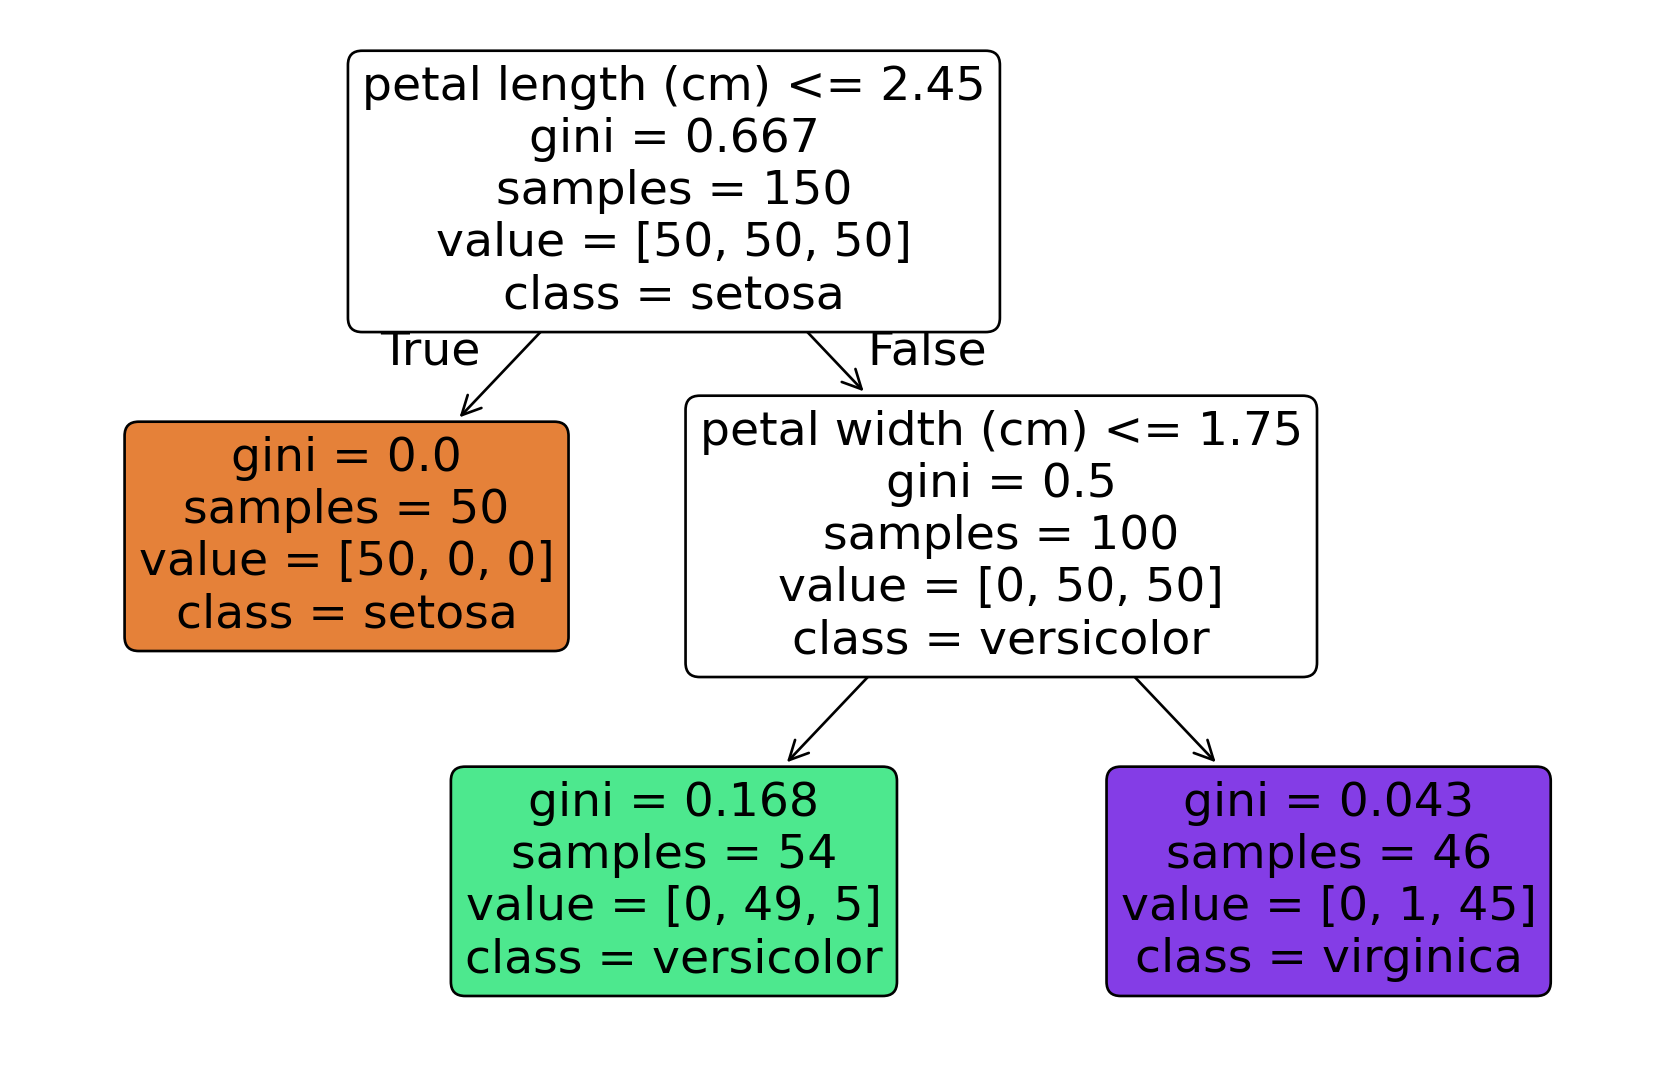

In [4]:
#| label: fig-iris-tree
#| fig-cap: Decision Tree trained on petal length and petal width from the Iris dataset.
#| code-fold: true
#| code-summary: Show code

fig, ax = plt.subplots(figsize=(11, 7))

plot_tree(
    tree_clf,
    feature_names=iris.feature_names[2:],
    class_names=iris.target_names,
    rounded=True,
    filled=True,
    impurity=True,
    proportion=False,
    ax=ax
)

plt.show()

In [5]:
#| label: example-tree-predictions

new_flowers = np.array([
    [1.5, 0.3],
    [5.0, 1.5],
    [6.0, 2.2]
])

tree_clf.predict(new_flowers)

array([0, 1, 2])

In [6]:
#| label: gini-calculation

counts = np.array([0, 49, 5])
probabilities = counts / counts.sum()

gini = 1 - np.sum(probabilities ** 2)
gini

np.float64(0.16803840877914955)

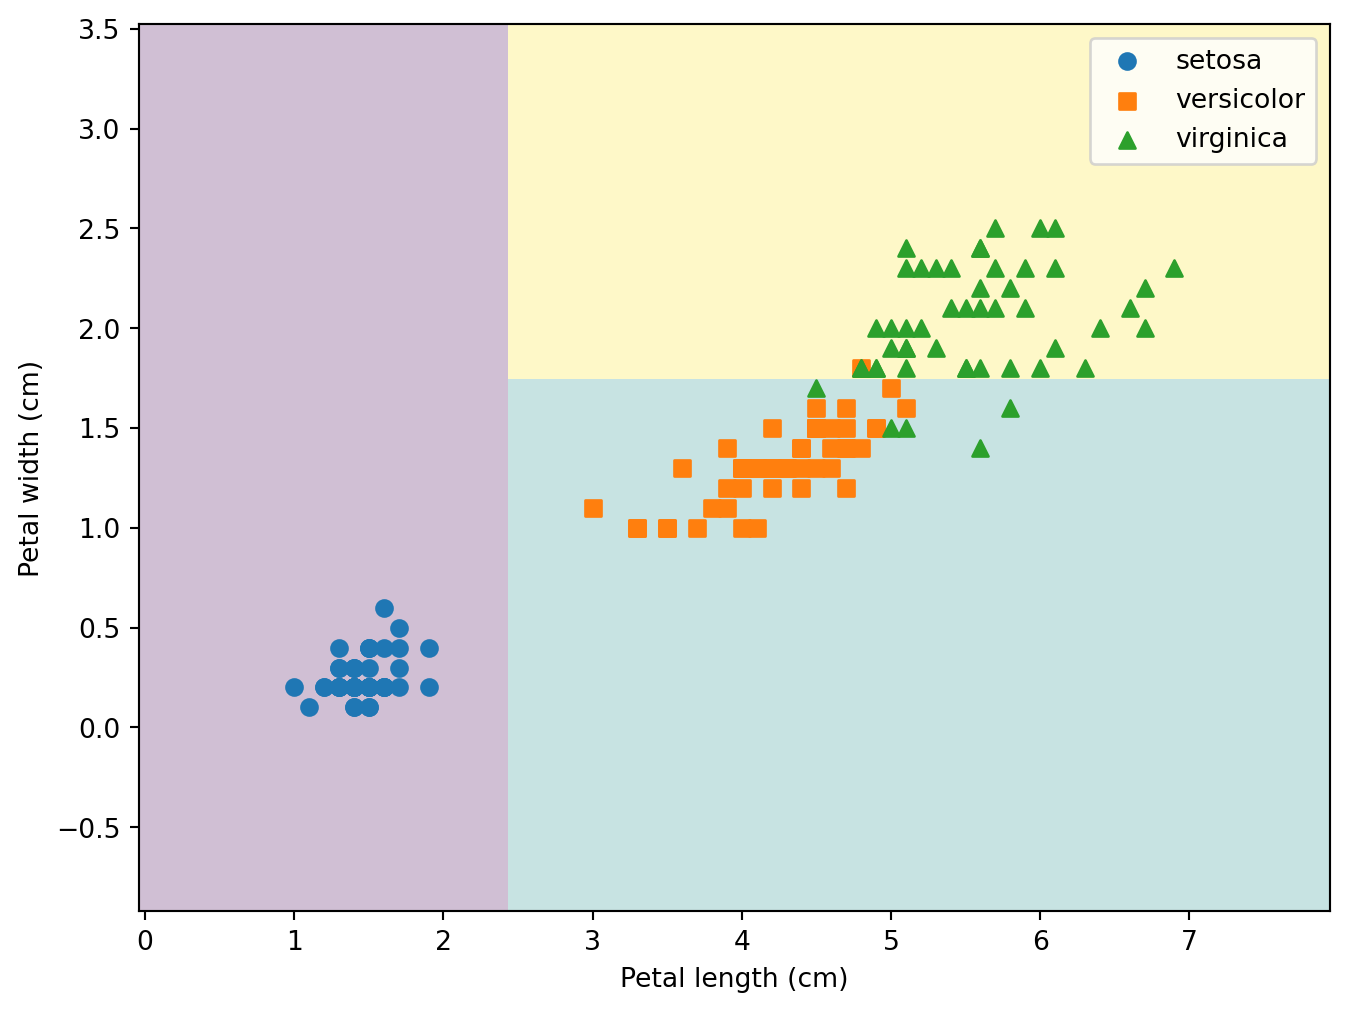

In [7]:
#| label: fig-tree-boundaries
#| fig-cap: Decision boundaries generated by a depth-two Decision Tree.
#| code-fold: true
#| code-summary: Show code

fig, ax = plt.subplots(figsize=(8, 6))

DecisionBoundaryDisplay.from_estimator(
    tree_clf,
    X,
    response_method="predict",
    plot_method="pcolormesh",
    alpha=0.25,
    ax=ax
)

for class_id, marker in zip(np.unique(y), ["o", "s", "^"]):
    ax.scatter(
        X[y == class_id, 0],
        X[y == class_id, 1],
        marker=marker,
        label=iris.target_names[class_id]
    )

ax.set_xlabel("Petal length (cm)")
ax.set_ylabel("Petal width (cm)")
ax.legend()
plt.show()

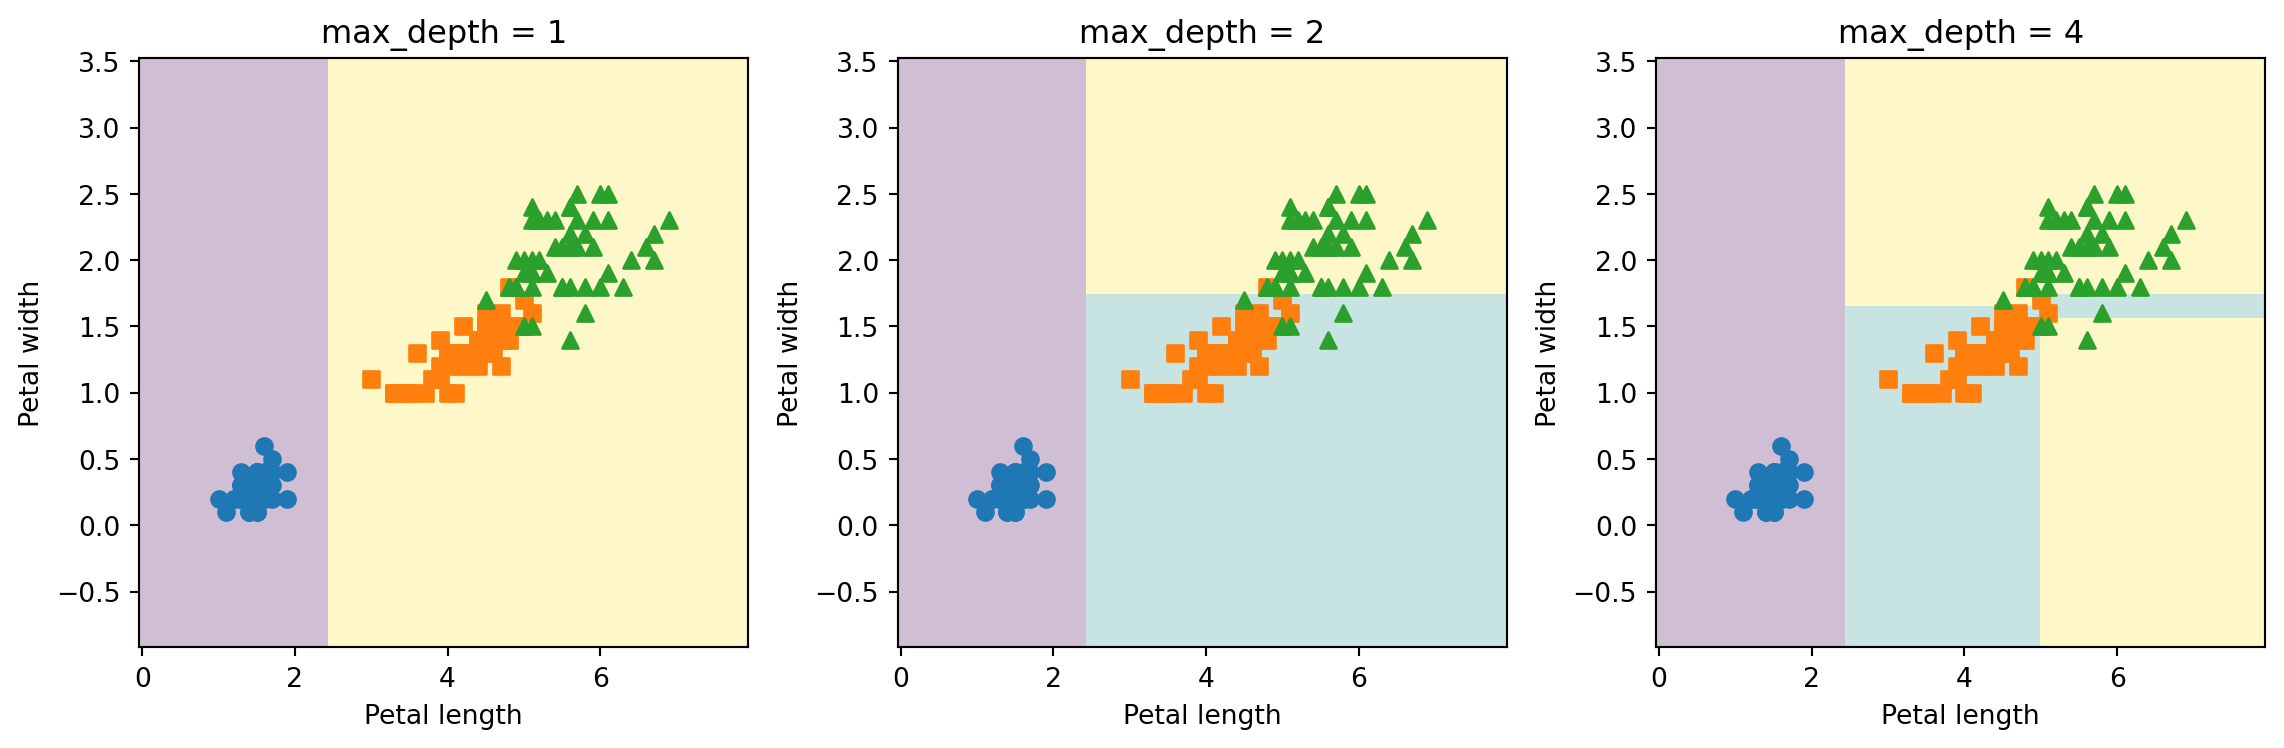

In [8]:
#| label: fig-tree-depths
#| fig-cap: Increasing tree depth creates increasingly detailed partitions.
#| code-fold: true
#| code-summary: Show code

depths = [1, 2, 4]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for depth, ax in zip(depths, axes):
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    model.fit(X, y)

    DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        response_method="predict",
        plot_method="pcolormesh",
        alpha=0.25,
        ax=ax
    )

    for class_id, marker in zip(np.unique(y), ["o", "s", "^"]):
        ax.scatter(
            X[y == class_id, 0],
            X[y == class_id, 1],
            marker=marker
        )

    ax.set_title(f"max_depth = {depth}")
    ax.set_xlabel("Petal length")
    ax.set_ylabel("Petal width")

plt.tight_layout()
plt.show()

In [9]:
#| label: class-probabilities

tree_clf.predict_proba([[5, 1.5]])

array([[0.        , 0.90740741, 0.09259259]])

In [10]:
#| label: class-prediction

tree_clf.predict([[5, 1.5]])

array([1])

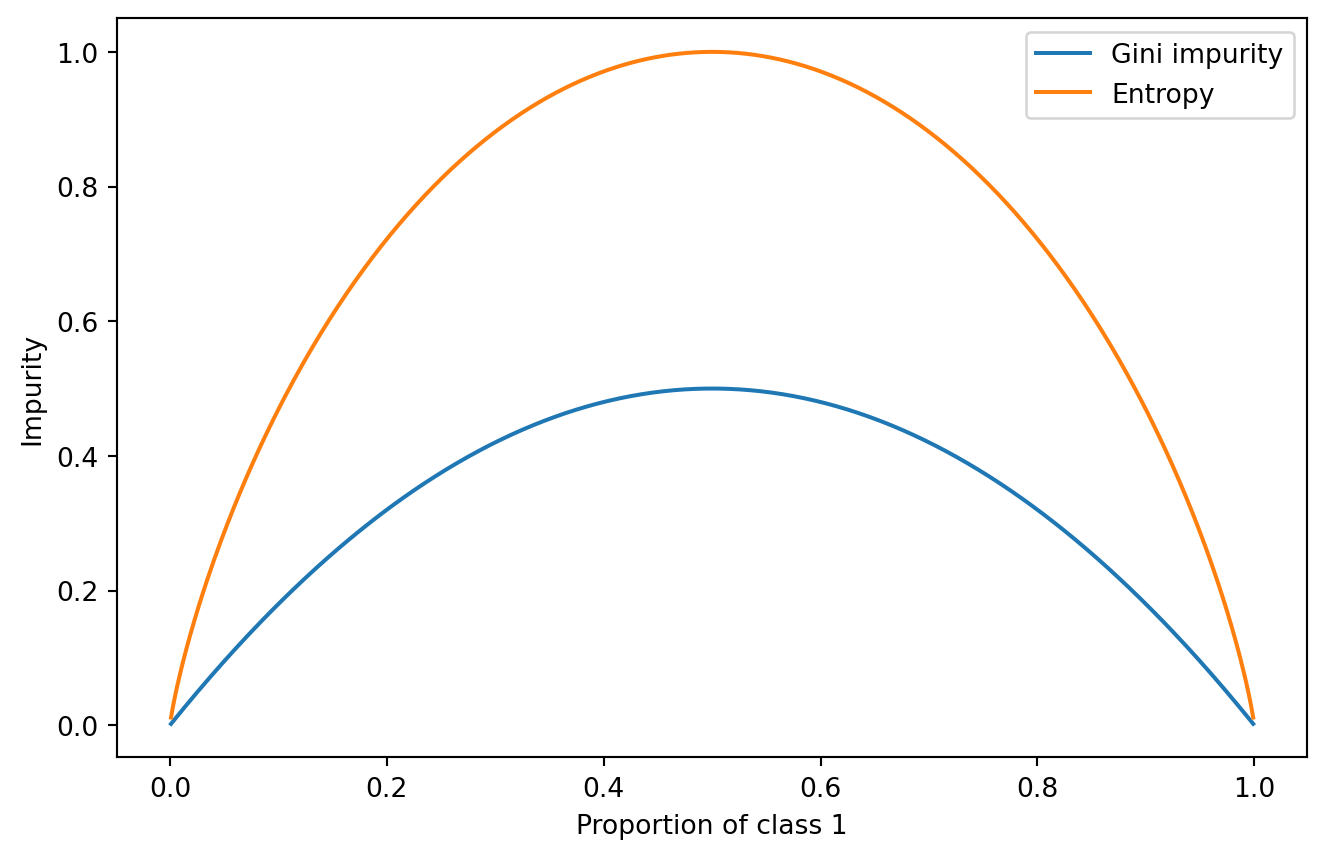

In [11]:
#| label: impurity-functions
#| fig-cap: Gini impurity and entropy for a binary classification node.
#| code-fold: true
#| code-summary: Show code

p = np.linspace(0.001, 0.999, 500)

gini_curve = 1 - p**2 - (1 - p)**2
entropy_curve = -p * np.log2(p) - (1 - p) * np.log2(1 - p)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p, gini_curve, label="Gini impurity")
ax.plot(p, entropy_curve, label="Entropy")
ax.set_xlabel("Proportion of class 1")
ax.set_ylabel("Impurity")
ax.legend()
plt.show()

In [12]:
#| label: compare-criteria

gini_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

entropy_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

gini_tree.fit(X, y)
entropy_tree.fit(X, y)

gini_tree.get_n_leaves(), entropy_tree.get_n_leaves()

(np.int64(5), np.int64(5))

In [13]:
#| label: make-moons-data

X_moons, y_moons = make_moons(
    n_samples=500,
    noise=0.30,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X_moons,
    y_moons,
    test_size=0.30,
    stratify=y_moons,
    random_state=42
)

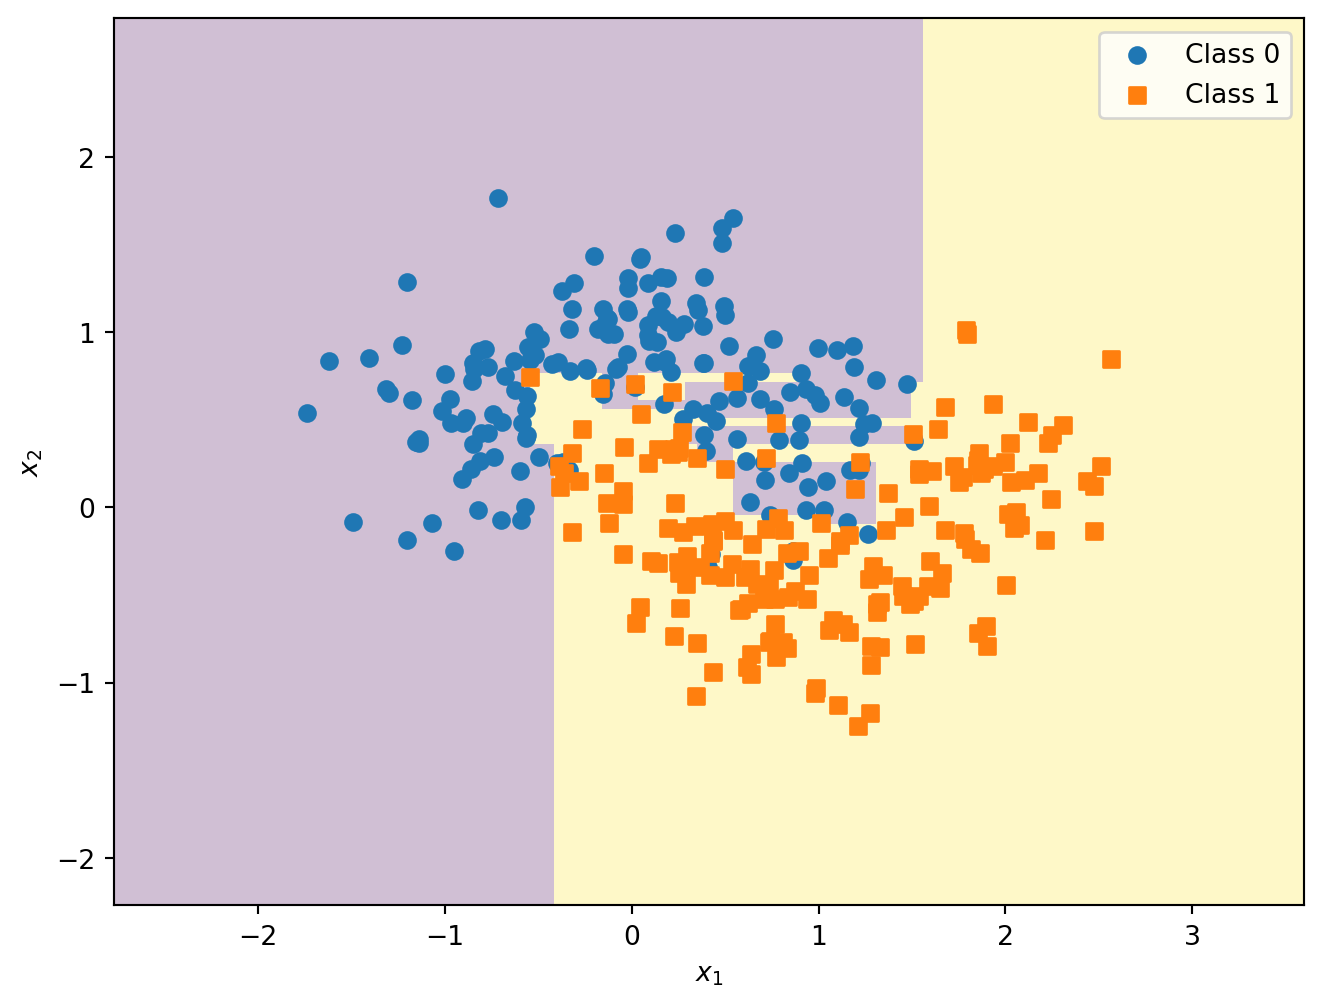

In [14]:
#| label: fig-unregularized-tree
#| fig-cap: An unrestricted tree creates an irregular boundary on noisy data.
#| code-fold: true
#| code-summary: Show code

unregularized_tree = DecisionTreeClassifier(
    random_state=42
)

unregularized_tree.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(8, 6))

DecisionBoundaryDisplay.from_estimator(
    unregularized_tree,
    X_train,
    response_method="predict",
    plot_method="pcolormesh",
    alpha=0.25,
    ax=ax
)

ax.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    marker="o",
    label="Class 0"
)

ax.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    marker="s",
    label="Class 1"
)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend()
plt.show()

In [15]:
#| label: unregularized-scores

train_accuracy = accuracy_score(
    y_train,
    unregularized_tree.predict(X_train)
)

test_accuracy = accuracy_score(
    y_test,
    unregularized_tree.predict(X_test)
)

train_accuracy, test_accuracy

(1.0, 0.8666666666666667)

In [16]:
#| label: regularized-tree

regularized_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

regularized_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)

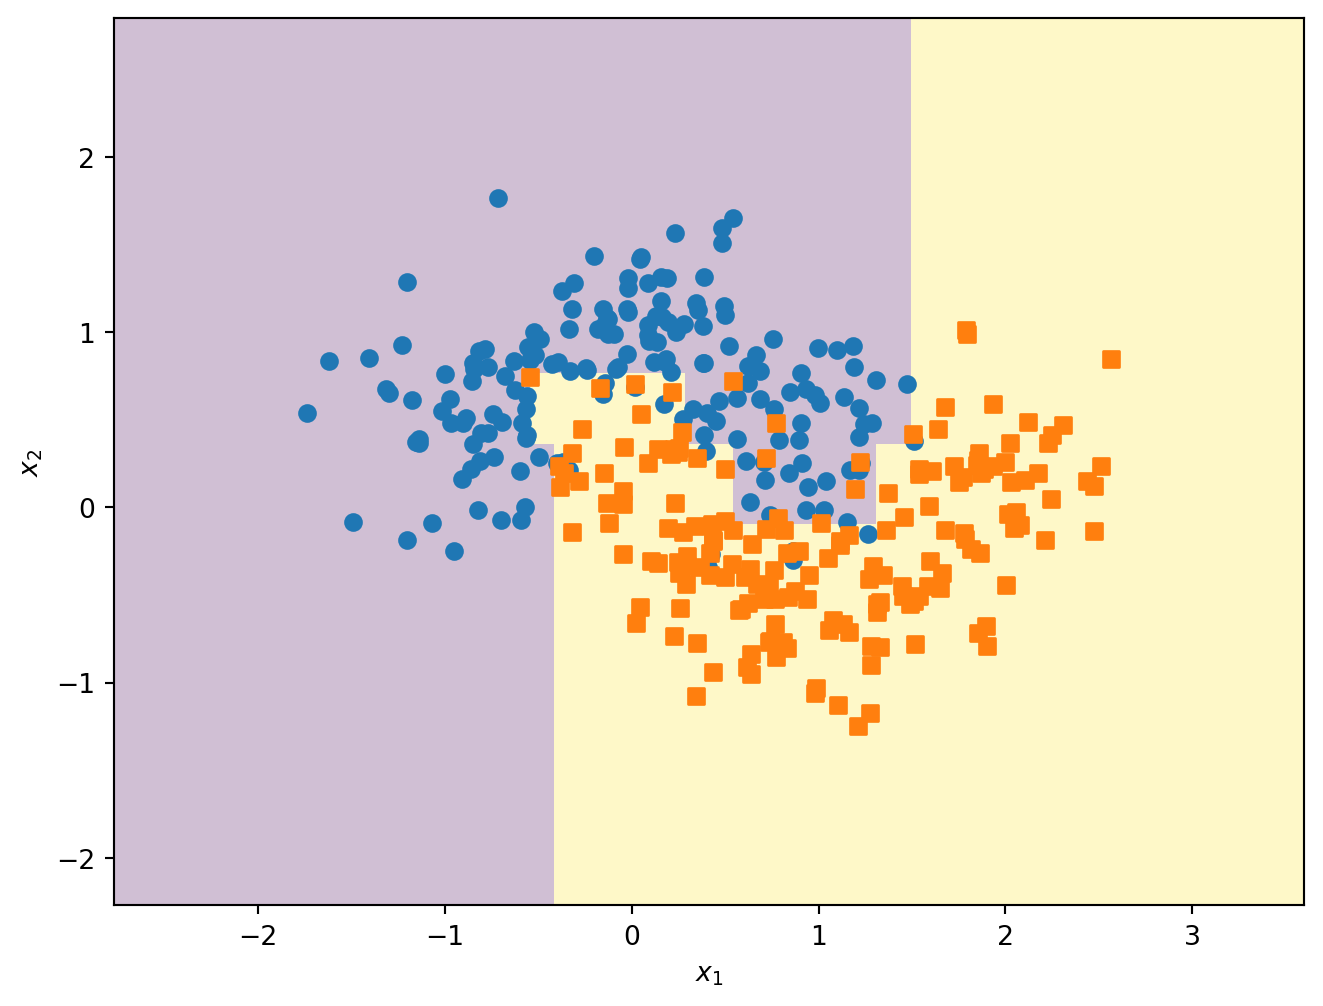

In [17]:
#| label: fig-regularized-tree
#| fig-cap: Regularization produces a smoother and more stable decision boundary.
#| code-fold: true
#| code-summary: Show code

fig, ax = plt.subplots(figsize=(8, 6))

DecisionBoundaryDisplay.from_estimator(
    regularized_tree,
    X_train,
    response_method="predict",
    plot_method="pcolormesh",
    alpha=0.25,
    ax=ax
)

ax.scatter(
    X_train[y_train == 0, 0],
    X_train[y_train == 0, 1],
    marker="o"
)

ax.scatter(
    X_train[y_train == 1, 0],
    X_train[y_train == 1, 1],
    marker="s"
)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
plt.show()

In [18]:
#| label: regularized-scores

regularized_train_accuracy = accuracy_score(
    y_train,
    regularized_tree.predict(X_train)
)

regularized_test_accuracy = accuracy_score(
    y_test,
    regularized_tree.predict(X_test)
)

regularized_train_accuracy, regularized_test_accuracy

(0.9457142857142857, 0.8933333333333333)

In [19]:
#| label: pruning-path

full_tree = DecisionTreeClassifier(
    random_state=42
)

path = full_tree.cost_complexity_pruning_path(
    X_train,
    y_train
)

ccp_alphas = path.ccp_alphas
impurities = path.impurities

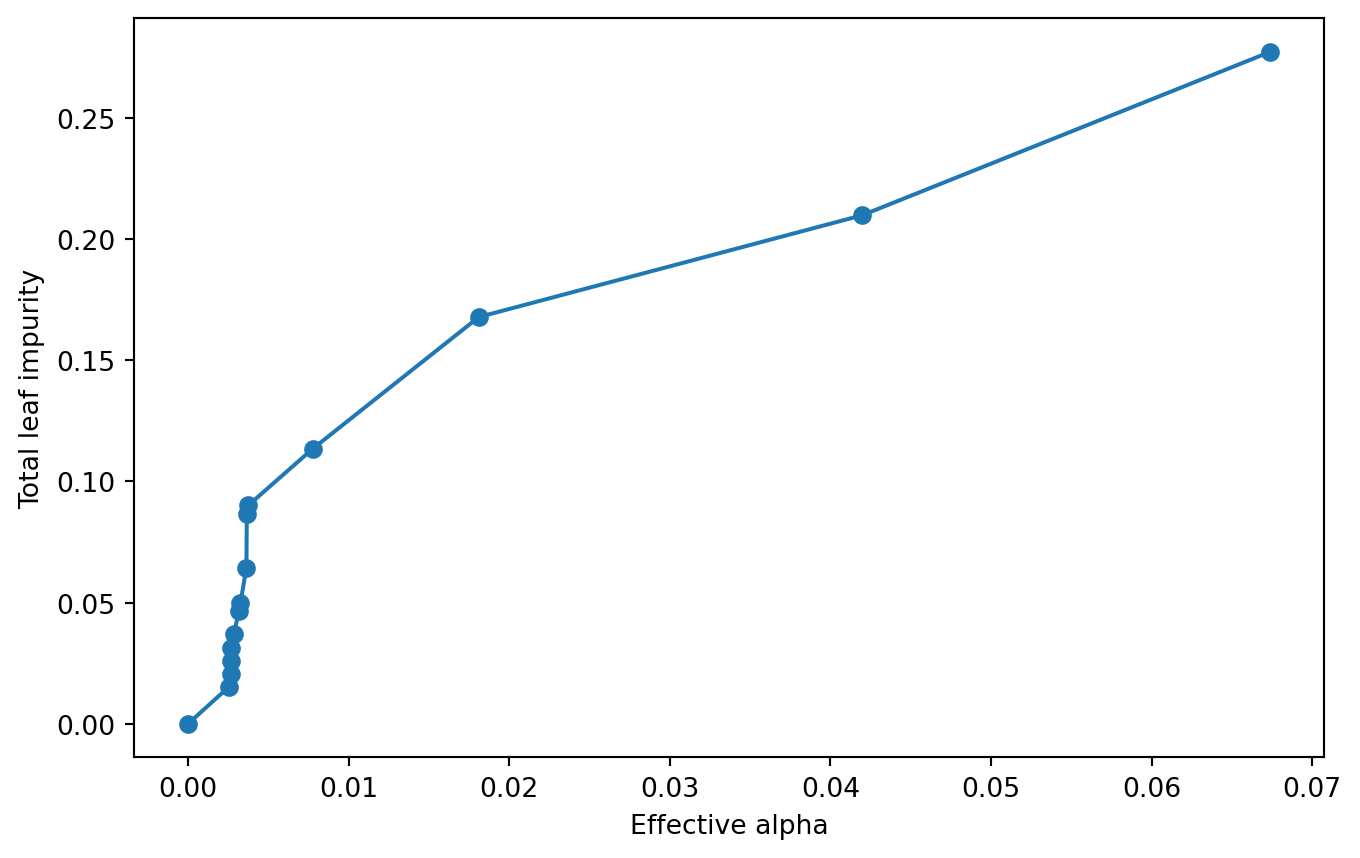

In [20]:
#| label: fig-pruning-path
#| fig-cap: Cost-complexity pruning path for the training data.
#| code-fold: true
#| code-summary: Show code

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o")
ax.set_xlabel("Effective alpha")
ax.set_ylabel("Total leaf impurity")
plt.show()

In [21]:
#| label: pruning-models

pruned_trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha
    )
    model.fit(X_train, y_train)
    pruned_trees.append(model)

node_counts = [model.tree_.node_count for model in pruned_trees]
tree_depths = [model.tree_.max_depth for model in pruned_trees]

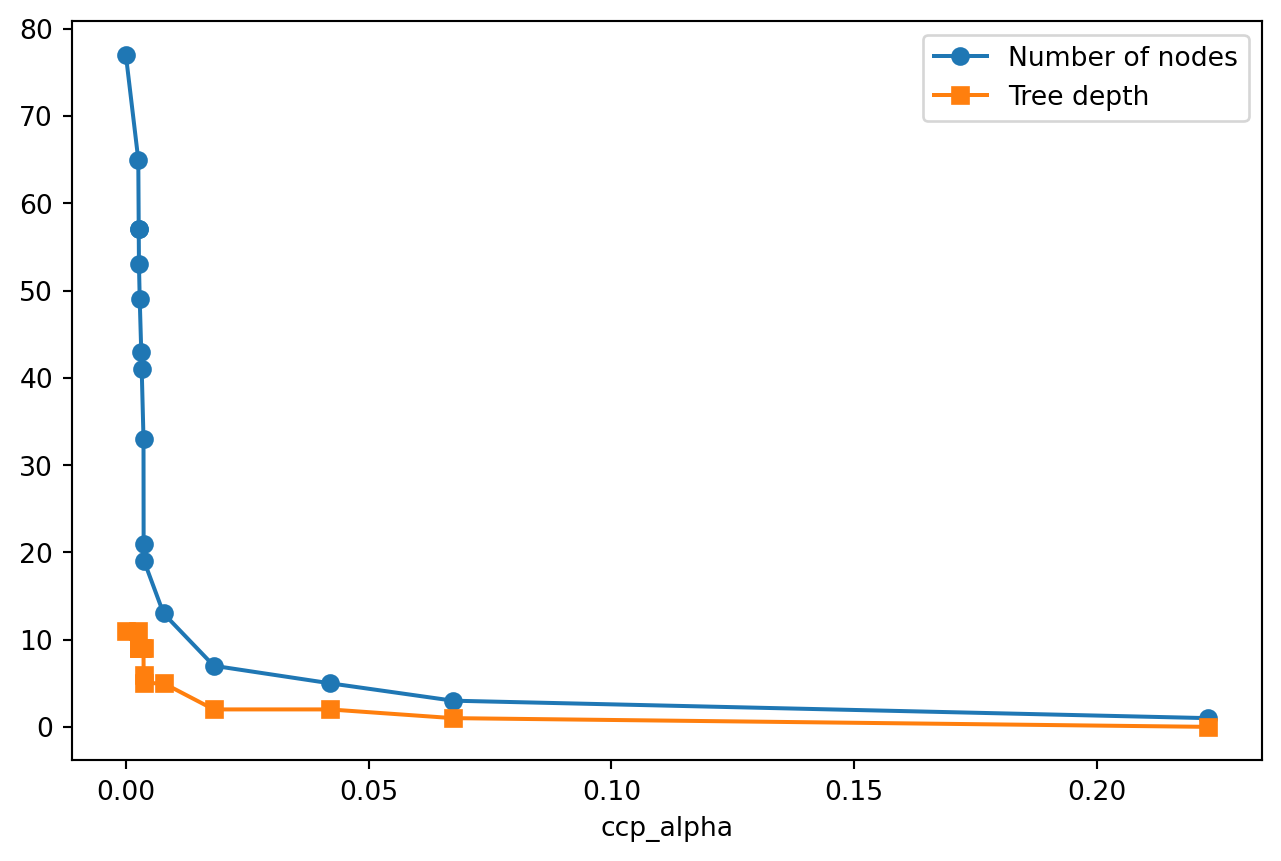

In [22]:
#| label: fig-pruning-complexity
#| fig-cap: Tree size decreases as the pruning penalty increases.
#| code-fold: true
#| code-summary: Show code

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ccp_alphas, node_counts, marker="o", label="Number of nodes")
ax.plot(ccp_alphas, tree_depths, marker="s", label="Tree depth")
ax.set_xlabel("ccp_alpha")
ax.legend()
plt.show()

In [23]:
#| label: iris-feature-importance

importance_tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

importance_tree.fit(iris.data, iris.target)

dict(
    zip(
        iris.feature_names,
        importance_tree.feature_importances_
    )
)

{'sepal length (cm)': np.float64(0.0),
 'sepal width (cm)': np.float64(0.01351351351351351),
 'petal length (cm)': np.float64(0.5581648224311269),
 'petal width (cm)': np.float64(0.42832166405535965)}

In [24]:
#| label: regression-data

rng = np.random.default_rng(42)

X_reg = 2 * rng.random((200, 1)) - 1

y_reg = (
    0.5 * X_reg[:, 0] ** 2
    + 0.1 * X_reg[:, 0]
    + rng.normal(0, 0.05, 200)
)

In [25]:
#| label: regression-trees

tree_reg_depth_2 = DecisionTreeRegressor(
    max_depth=2,
    random_state=42
)

tree_reg_depth_3 = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

tree_reg_depth_2.fit(X_reg, y_reg)
tree_reg_depth_3.fit(X_reg, y_reg)

DecisionTreeRegressor(max_depth=3, random_state=42)

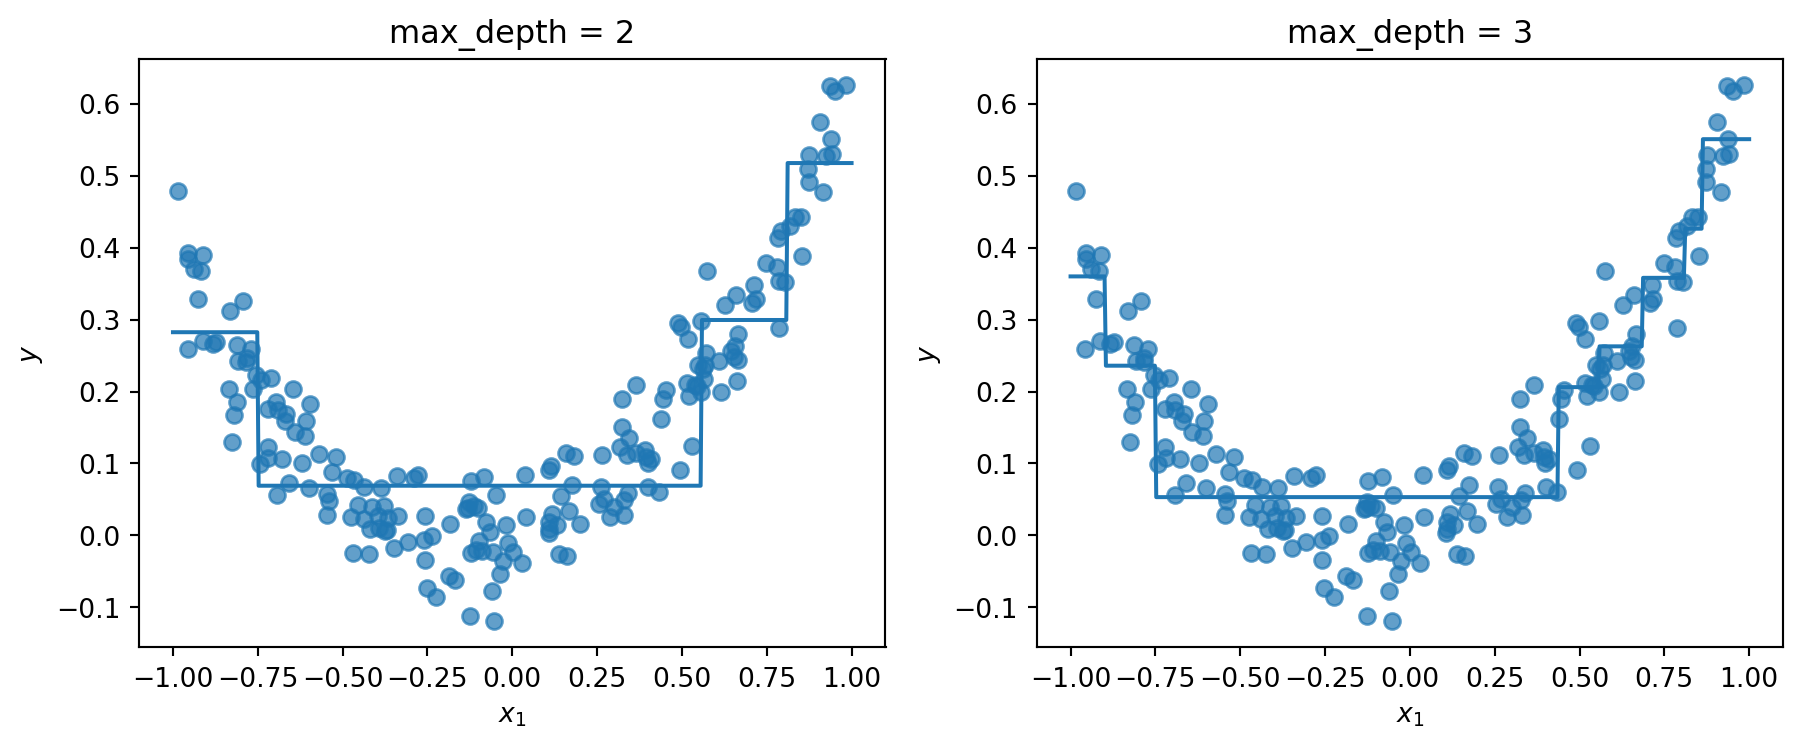

In [26]:
#| label: fig-regression-trees
#| fig-cap: Regression trees produce piecewise-constant predictions.
#| code-fold: true
#| code-summary: Show code

x_plot = np.linspace(-1, 1, 500).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))

for model, depth, ax in zip(
    [tree_reg_depth_2, tree_reg_depth_3],
    [2, 3],
    axes
):
    predictions = model.predict(x_plot)

    ax.scatter(X_reg[:, 0], y_reg, alpha=0.7)
    ax.plot(x_plot[:, 0], predictions)
    ax.set_title(f"max_depth = {depth}")
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$y$")

plt.tight_layout()
plt.show()

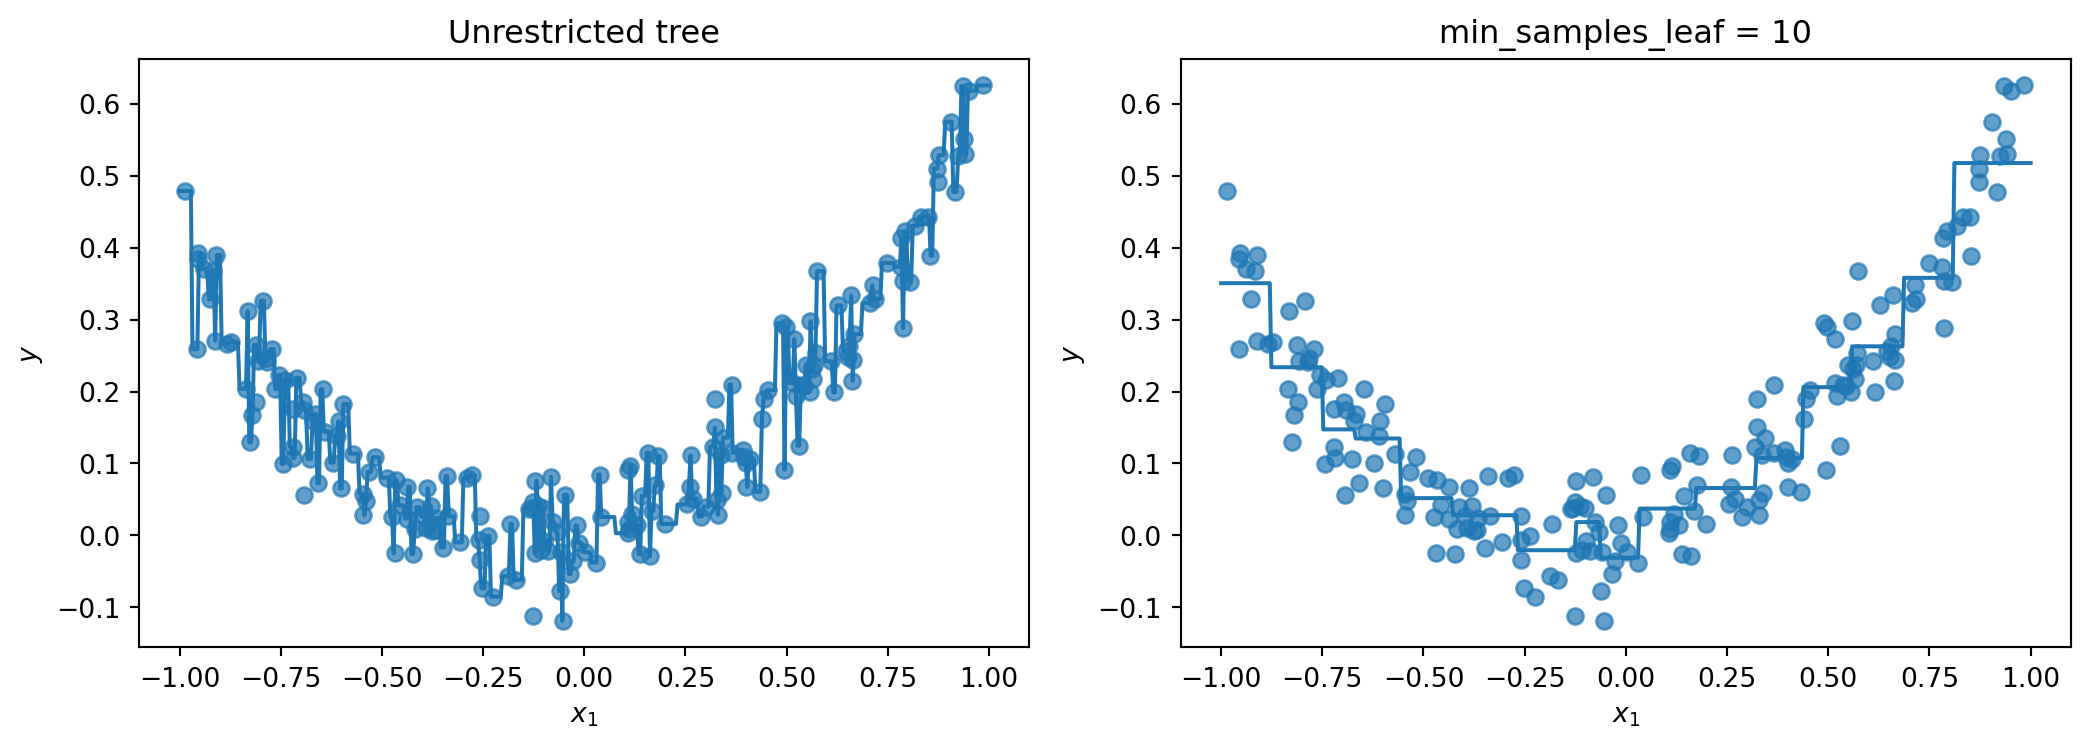

In [27]:
#| label: fig-regression-overfitting
#| fig-cap: An unrestricted regression tree follows noise in the training data.
#| code-fold: true
#| code-summary: Show code

unrestricted_reg = DecisionTreeRegressor(
    random_state=42
)

regularized_reg = DecisionTreeRegressor(
    min_samples_leaf=10,
    random_state=42
)

unrestricted_reg.fit(X_reg, y_reg)
regularized_reg.fit(X_reg, y_reg)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for model, title, ax in zip(
    [unrestricted_reg, regularized_reg],
    ["Unrestricted tree", "min_samples_leaf = 10"],
    axes
):
    predictions = model.predict(x_plot)

    ax.scatter(X_reg[:, 0], y_reg, alpha=0.7)
    ax.plot(x_plot[:, 0], predictions)
    ax.set_title(title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$y$")

plt.tight_layout()
plt.show()

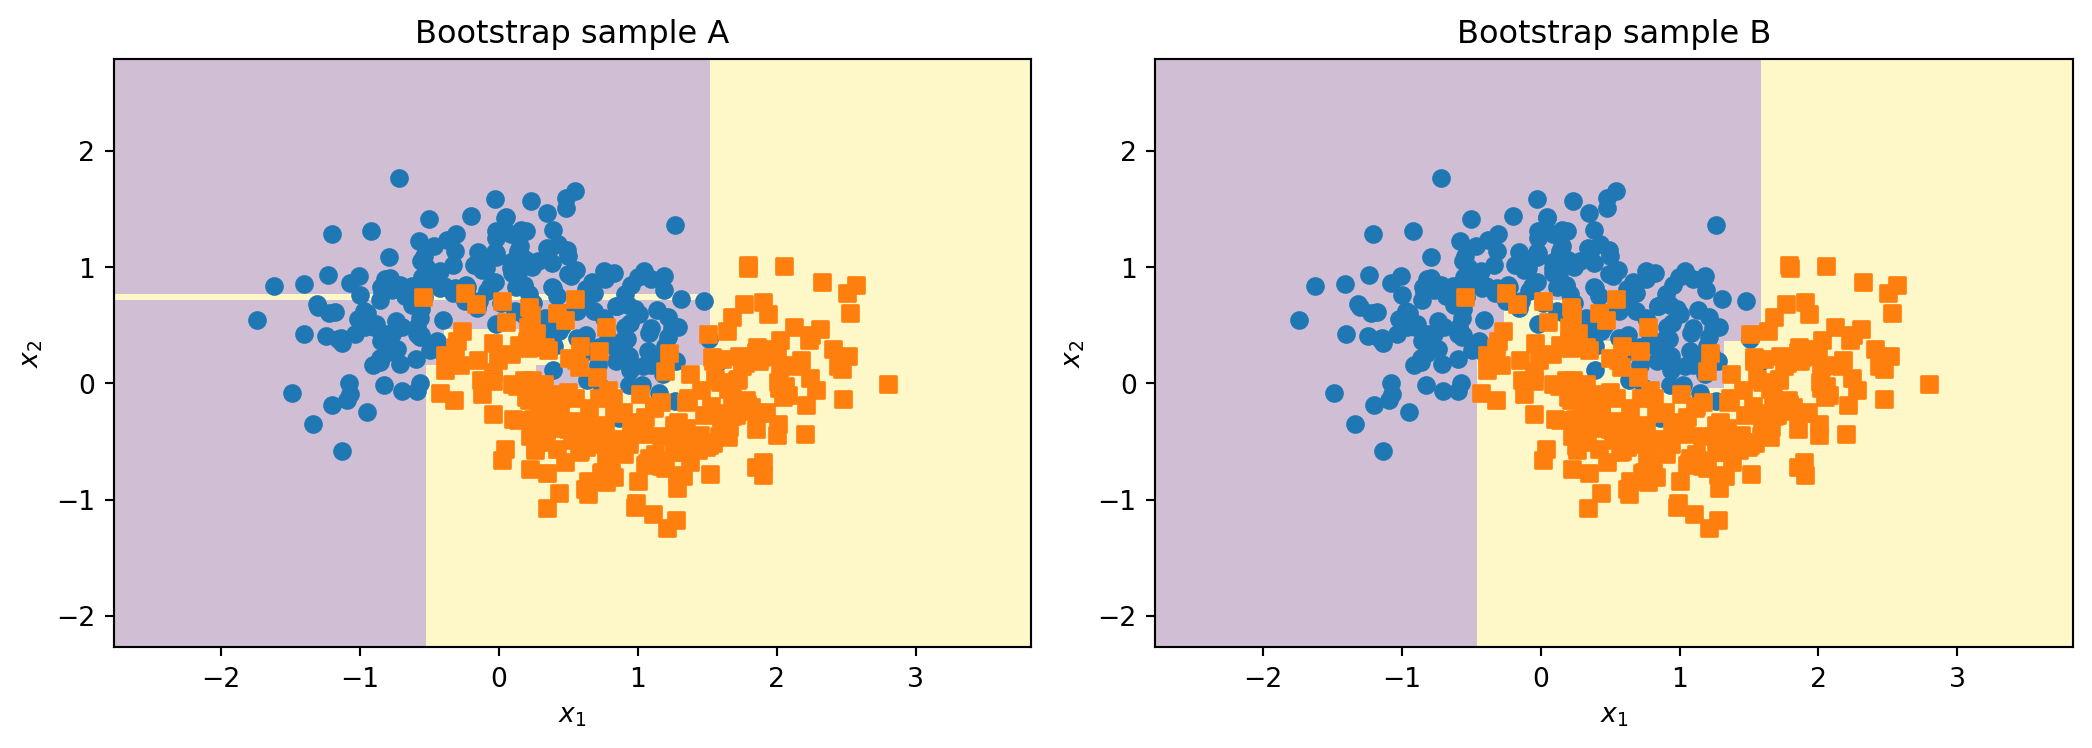

In [28]:
#| label: fig-tree-instability
#| fig-cap: Two trees trained after a small change in the data may produce different partitions.
#| code-fold: true
#| code-summary: Show code

rng = np.random.default_rng(42)

indices_a = rng.choice(
    len(X_moons),
    size=len(X_moons),
    replace=True
)

indices_b = rng.choice(
    len(X_moons),
    size=len(X_moons),
    replace=True
)

tree_a = DecisionTreeClassifier(
    max_depth=5,
    random_state=1
)

tree_b = DecisionTreeClassifier(
    max_depth=5,
    random_state=2
)

tree_a.fit(
    X_moons[indices_a],
    y_moons[indices_a]
)

tree_b.fit(
    X_moons[indices_b],
    y_moons[indices_b]
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for model, title, ax in zip(
    [tree_a, tree_b],
    ["Bootstrap sample A", "Bootstrap sample B"],
    axes
):
    DecisionBoundaryDisplay.from_estimator(
        model,
        X_moons,
        response_method="predict",
        plot_method="pcolormesh",
        alpha=0.25,
        ax=ax
    )

    ax.scatter(
        X_moons[y_moons == 0, 0],
        X_moons[y_moons == 0, 1],
        marker="o"
    )

    ax.scatter(
        X_moons[y_moons == 1, 0],
        X_moons[y_moons == 1, 1],
        marker="s"
    )

    ax.set_title(title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

plt.tight_layout()
plt.show()

In [29]:
#| label: tree-versus-extra-tree

decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

extra_tree = ExtraTreeClassifier(
    max_depth=5,
    random_state=42
)

decision_tree.fit(X_train, y_train)
extra_tree.fit(X_train, y_train)

ExtraTreeClassifier(max_depth=5, random_state=42)

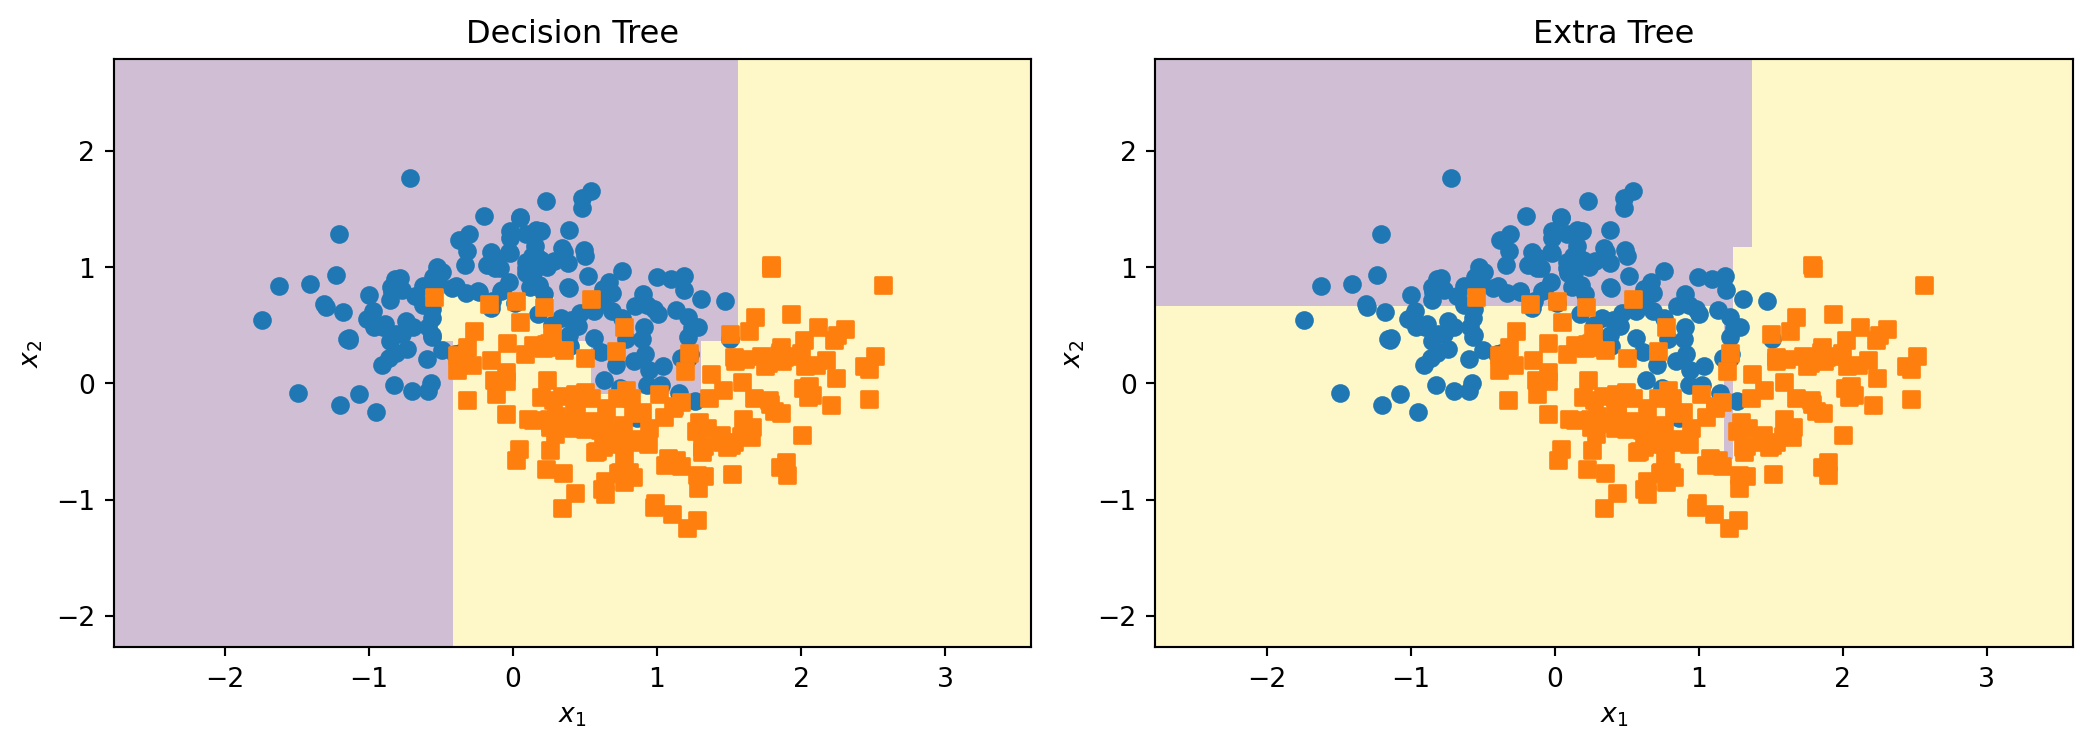

In [30]:
#| label: fig-tree-extra-tree
#| fig-cap: Decision boundary from a standard Decision Tree and a randomized Extra Tree.
#| code-fold: true
#| code-summary: Show code

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for model, title, ax in zip(
    [decision_tree, extra_tree],
    ["Decision Tree", "Extra Tree"],
    axes
):
    DecisionBoundaryDisplay.from_estimator(
        model,
        X_train,
        response_method="predict",
        plot_method="pcolormesh",
        alpha=0.25,
        ax=ax
    )

    ax.scatter(
        X_train[y_train == 0, 0],
        X_train[y_train == 0, 1],
        marker="o"
    )

    ax.scatter(
        X_train[y_train == 1, 0],
        X_train[y_train == 1, 1],
        marker="s"
    )

    ax.set_title(title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

plt.tight_layout()
plt.show()

In [31]:
#| label: practical-tree

final_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)